# Step 8 (Full run): KITTI reliability panel and per-knob confound ratios

**This is the scale-up clone.** Identical to the pilot notebook except the Knob 1 strengths default to the values that passed the gate on the pilot (`JITTER_STD = 0.35`, `CLUTTER_FRAC = 0.60`). The gate still runs and still decides.

**Status:** the KITTI stage of the audit. Step 7 verified the pipeline and exposed one problem: the LiDAR Knob 1 (uniform dropout + weak jitter) produced **no accuracy drop**, meaning S_q would be ~0 and the confound ratio meaningless. This notebook fixes the knob first, gates on the fix, then runs the panel.

**Structure:**

1. **Gate:** Knob 1 v2 for LiDAR (range jitter + clutter returns). The notebook refuses to continue until the corruption demonstrably degrades the LiDAR head
2. **Panel:** four reliability methods through one shared harness
3. **Audit:** three knobs on a shared [0,1] severity axis, slopes S_q and S_a fitted per method **per knob**
4. **Output:** the taxonomy table and figures

**The panel and the prediction:**

| Method | Design | Consumes | Predicted ratio (2a) | Predicted ratio (2b) |
|---|---|---|---|---|
| TMC | isolated | own points only | ~0 | ~0 |
| Deep ensembles | isolated | own points only | ~0 | ~0 |
| Coupled decision (JS) | coupled | both views' predictions | large | **~0 (blind)** |
| Coupled spatial (proj. consistency) | coupled | points + box + T_used | large | large |

**The ~0 in the JS row under Knob 2b is itself a finding:** a coupled method can pass one misalignment audit and fail another. Misalignment type matters, which is exactly why S_a must be reported per knob.

**Audited modality:** LiDAR throughout (the sensor that calibration drift gets blamed on). Camera stays clean, mirroring the single-audited-view design of Steps 5 and 6.


In [1]:
# ============ CONFIG + LOAD STEP 7 ARTIFACTS ============
from pathlib import Path
import numpy as np, pandas as pd, torch
import torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
rng  = np.random.default_rng(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# knob 1 v2 strength (severity 1 values)
JITTER_STD   = 0.35   # meters of range noise per coordinate (gate-passing value from the pilot)
CLUTTER_FRAC = 0.60   # fraction of returns replaced by clutter (gate-passing value from the pilot)

# knob 2b strength (severity 1 values), same as Step 7
MAX_ROT_DEG  = 2.0
MAX_TRANS_M  = 0.20

SEVS   = np.array([0.0, 0.25, 0.5, 0.75, 1.0])   # shared severity grid, all knobs
DRAWS  = 3                                        # random repeats averaged per point
TMC_EPOCHS, ENS_EPOCHS, ENS_M = 60, 20, 5

blob = torch.load("step7_kitti_objects.pt", weights_only=False)
samples, calibs   = blob["samples"], blob["calibs"]
CLASSES           = blob["classes"];  K = len(CLASSES)
tr_idx, te_idx    = blob["tr_idx"], blob["te_idx"]
N_POINTS          = blob["n_points"]

to_crop = lambda s: torch.from_numpy(s["crop"].copy()).float().permute(2, 0, 1) / 255.0
tr_crops  = torch.stack([to_crop(samples[i]) for i in tr_idx])
te_crops  = torch.stack([to_crop(samples[i]) for i in te_idx])
tr_points = torch.stack([torch.from_numpy(samples[i]["points"]).float() for i in tr_idx])
te_points = torch.stack([torch.from_numpy(samples[i]["points"]).float() for i in te_idx])
y_tr = torch.tensor([samples[i]["label"] for i in tr_idx])
y_te = torch.tensor([samples[i]["label"] for i in te_idx])
velo_base   = [samples[i]["pts_velo_raw"].astype(np.float64) for i in te_idx]
frames_test = sorted({samples[i]["frame_id"] for i in te_idx})
n_te = len(te_idx)
print(f"device={DEVICE}  train={len(tr_idx)}  test={n_te}  classes={CLASSES}")
if n_te < 150:
    print(f"NOTE: {n_te} test objects is fine for development but noisy for slope fits.")
    print("For paper numbers rerun Step 7 with N_FRAMES around 500 to 1000, then rerun this notebook unchanged.")


device=cuda  train=5223  test=2247  classes=['Car', 'Pedestrian', 'Cyclist']


In [ ]:
# ============ GEOMETRY CORE (unit-tested, identical to Step 7) ============
import numpy as np

# ---------- Calibration ----------

def parse_calib(calib_path):
    with open(calib_path) as f:
        for line in f:
            if ':' not in line:
                continue
            key, vals = line.split(':', 1)
            data[key.strip()] = np.array([float(v) for v in vals.split()])
    P2 = data['P2'].reshape(3, 4)
    R0 = np.eye(4)
    R0[:3, :3] = data['R0_rect'].reshape(3, 3)
    Tr = np.eye(4)
    Tr[:3, :4] = data['Tr_velo_to_cam'].reshape(3, 4)
    return {'P2': P2, 'R0_rect': R0, 'Tr_velo_cam': Tr}


def velo_to_rect(pts_velo, Tr_velo_cam, R0_rect):
    n = pts_velo.shape[0]
    hom = np.hstack([pts_velo, np.ones((n, 1))])          
    rect = (R0_rect @ Tr_velo_cam @ hom.T).T              
    return rect[:, :3]


def rect_to_image(pts_rect, P2):
    n = pts_rect.shape[0]
    hom = np.hstack([pts_rect, np.ones((n, 1))])          
    proj = (P2 @ hom.T).T                                  
    depth = proj[:, 2]
    uv = proj[:, :2] / np.clip(depth[:, None], 1e-6, None)
    return uv, depth


def rot_y(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c, 0, s], [0, 1, 0], [-c * 0 - s, 0, c]])


def points_in_3d_box(pts_rect, center, dims, ry, margin=0.0):
    h, w, l = dims
    p = pts_rect - np.asarray(center)                      
    c, s = np.cos(-ry), np.sin(-ry)
    x =  c * p[:, 0] + s * p[:, 2]
    z = -s * p[:, 0] + c * p[:, 2]
    y = p[:, 1]
    return (
        (np.abs(x) <= l / 2 + margin) &
        (np.abs(z) <= w / 2 + margin) &
        (y <= 0 + margin) & (y >= -h - margin)
    )


def canonicalize_points(pts_rect, center, dims, ry):
    h, _, _ = dims
    mid = np.asarray(center, dtype=float).copy()
    mid[1] -= h / 2                                        
    p = pts_rect - mid
    c, s = np.cos(-ry), np.sin(-ry)
    out = np.empty_like(p)
    out[:, 0] =  c * p[:, 0] + s * p[:, 2]
    out[:, 2] = -s * p[:, 0] + c * p[:, 2]
    out[:, 1] = p[:, 1]
    return out


# ---------- Knob 2b: extrinsic perturbation ----------

def small_rotation(axis, angle):
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    return np.eye(3) + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)


def perturb_extrinsics(Tr_velo_cam, severity, rng,
                       max_rot_deg=2.0, max_trans_m=0.20):
    T = Tr_velo_cam.copy()
    if severity == 0:
        return T
    axis = rng.normal(size=3)
    dR = small_rotation(axis, np.deg2rad(max_rot_deg * severity))
    direc = rng.normal(size=3)
    direc = direc / np.linalg.norm(direc)
    dt = direc * (max_trans_m * severity)
    T[:3, :3] = dR @ T[:3, :3]
    T[:3, 3] = dR @ T[:3, 3] + dt
    return T


def projection_consistency(pts_velo, box2d, calib, Tr_used):
    if pts_velo.shape[0] == 0:
        return 0.0
    rect = velo_to_rect(pts_velo, Tr_used, calib['R0_rect'])
    uv, depth = rect_to_image(rect, calib['P2'])
    x1, y1, x2, y2 = box2d
    inside = (
        (depth > 0) &
        (uv[:, 0] >= x1) & (uv[:, 0] <= x2) &
        (uv[:, 1] >= y1) & (uv[:, 1] <= y2)
    )
    return float(inside.mean())


## 1. Gate: Knob 1 v2 for LiDAR

**Why Step 7's version failed, in one breath:** the PointNet head classifies mostly by the cloud's **extent and silhouette** (a car spans 4 m, a pedestrian 0.6 m). Uniform dropout keeps the extent, and 0.1 m jitter is invisible next to meter-scale class gaps. Max pooling shrugs both off.

**The v2 corruption attacks the cue the classifier actually uses, with physical grounding:**

- **Range jitter** (std up to 0.20 m per coordinate): heavy rain and fog range noise
- **Clutter returns** (up to 40% of points replaced): rain, dust, and multipath returns scattered in an inflated bounding volume, which directly corrupts the silhouette

**The same process is applied in both representations** the pipeline uses: the canonicalized 128-point tensors (what the neural methods eat) and the raw velodyne points (what the spatial coupling eats). Isotropic jitter is exactly frame-equivalent under the rigid canonicalization; the clutter volume is the point set's own inflated bounding box in each frame.

**The gate below must print PASS.** If it fails, raise `JITTER_STD` or `CLUTTER_FRAC` and rerun. Do not proceed with a flat Knob 1: S_q near zero turns every confound ratio downstream into noise.


In [ ]:
# ============ KNOB 1 V2 + GATE ============
def corrupt_points_canon(points, severity, rng):
    pts = points.clone()
    if severity == 0:
        return pts
    pts[..., :3] += torch.from_numpy(
        rng.normal(0, JITTER_STD * severity, pts[..., :3].shape)).float()
    n_rep = int(CLUTTER_FRAC * severity * pts.shape[1])
    if n_rep > 0:
        for b in range(pts.shape[0]):
            xyz = pts[b, :, :3].numpy()
            lo, hi = xyz.min(0), xyz.max(0)
            ctr, span = (hi + lo) / 2, (hi - lo) * 1.2 + 1e-3
            sel = rng.choice(pts.shape[1], n_rep, replace=False)
            pts[b, sel, :3] = torch.from_numpy(
                ctr - span / 2 + rng.random((n_rep, 3)) * span).float()
            pts[b, sel, 3] = torch.from_numpy(rng.random(n_rep)).float()
    return pts

def corrupt_velo_raw(pv, severity, rng):
    if severity == 0:
        return pv
    out = pv + rng.normal(0, JITTER_STD * severity, pv.shape)
    n_rep = int(CLUTTER_FRAC * severity * len(out))
    if n_rep > 0:
        lo, hi = out.min(0), out.max(0)
        ctr, span = (hi + lo) / 2, (hi - lo) * 1.2 + 1e-3
        sel = rng.choice(len(out), n_rep, replace=False)
        out[sel] = ctr - span / 2 + rng.random((n_rep, 3)) * span
    return out

class PointNetMini(nn.Module):
    def __init__(self, n_cls):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv1d(4, 64, 1),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 256, 1), nn.BatchNorm1d(256), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, n_cls))
    def forward(self, x):
        return self.head(self.mlp(x.transpose(1, 2)).max(dim=2).values)

class CropCNN(nn.Module):
    def __init__(self, n_cls):
        super().__init__()
        def block(ci, co):
            return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co),
                                 nn.ReLU(), nn.MaxPool2d(2))
        self.net  = nn.Sequential(block(3, 32), block(32, 64), block(64, 128),
                                  nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.head = nn.Linear(128, n_cls)
    def forward(self, x):
        return self.head(self.net(x))

sd = torch.load("step7_kitti_nets.pt", weights_only=False)
lid7 = PointNetMini(K); lid7.load_state_dict(sd["lid"]); lid7.eval().to(DEVICE)
cam7 = CropCNN(K);      cam7.load_state_dict(sd["cam"]); cam7.eval().to(DEVICE)

@torch.no_grad()
def batched_probs(model, x, bs=256):
    out = []
    for i in range(0, len(x), bs):
        out.append(F.softmax(model(x[i:i+bs].to(DEVICE)), 1).cpu())
    return torch.cat(out)

acc = lambda p, y: (p.argmax(1) == y).float().mean().item()
g = np.random.default_rng(SEED + 10)
rows = []
for sev in SEVS:
    a = acc(batched_probs(lid7, corrupt_points_canon(te_points, sev, g)), y_te)
    rows.append(a); print(f"severity {sev:.2f}   LiDAR acc {a:.3f}")
drop = rows[0] - rows[-1]
print(f"\naccuracy drop at severity 1: {drop:.3f}")
if drop < 0.15:
    raise RuntimeError(
        f"GATE FAILED: drop {drop:.3f} < 0.15. Raise JITTER_STD / CLUTTER_FRAC and rerun this cell.")
print("GATE PASSED: Knob 1 v2 has real signal. The panel below is meaningful.")


severity 0.00   LiDAR acc 0.998
severity 0.25   LiDAR acc 0.957
severity 0.50   LiDAR acc 0.884
severity 0.75   LiDAR acc 0.671
severity 1.00   LiDAR acc 0.428

accuracy drop at severity 1: 0.571
GATE PASSED: Knob 1 v2 has real signal. The panel below is meaningful.


## 2. The panel

Four methods, one interface. Every method returns a **per-object unreliability score for the LiDAR view**, higher = less trusted, exactly like `u` in Steps 3 to 6.

- **TMC (isolated):** evidential trunks on each view (CropCNN and PointNet bodies, softplus evidence heads), trained with the Step 3 loss verbatim (Bayes-risk cross entropy + annealed KL, Dempster-Shafer combination in the joint loss). Signal: `u = K / S` of the LiDAR view
- **Deep ensembles (isolated):** M PointNet heads from different seeds. Signal: predictive entropy of the ensemble mean, as in Step 6
- **Coupled decision-level (JS):** Jensen-Shannon divergence between the LiDAR ensemble prediction and the clean camera prediction at the aligned positions. Port of the Step 6 clean-room coupled baseline
- **Coupled spatial (projection consistency):** `1 - fraction of the object's LiDAR points projecting inside its 2D box through T_used`. This is a heuristic real camera-LiDAR systems actually use for cross-sensor validation, so it is a **deployed coupled design**, not a self-built strawman

**Fairness note on S_q:** Knob 1 corrupts the LiDAR data everywhere downstream, so each method's S_q is measured through its own signal on the same corrupted data. The spatial method sees corrupted raw points, the neural methods see corrupted tensors, same process, same severities.


In [4]:
# ============ TMC ON KITTI (Step 3 components, verbatim losses) ============
class EvidCropNet(nn.Module):
    def __init__(self):
        super().__init__()
        def block(ci, co):
            return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co),
                                 nn.ReLU(), nn.MaxPool2d(2))
        self.trunk = nn.Sequential(block(3, 32), block(32, 64), block(64, 128),
                                   nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(128, K))
    def forward(self, x):
        return F.softplus(self.trunk(x))

class EvidPointNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv1d(4, 64, 1),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 256, 1), nn.BatchNorm1d(256), nn.ReLU())
        self.head = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, K))
    def forward(self, x):
        return F.softplus(self.head(self.mlp(x.transpose(1, 2)).max(dim=2).values))

def to_belief_uncert(alpha):
    S = alpha.sum(1, keepdim=True)
    return (alpha - 1) / S, K / S

def ds_combine(alpha1, alpha2):
    b1, u1 = to_belief_uncert(alpha1)
    b2, u2 = to_belief_uncert(alpha2)
    bb = b1.unsqueeze(2) * b2.unsqueeze(1)
    conflict = bb.sum((1, 2)) - (b1 * b2).sum(1)
    denom = (1 - conflict).unsqueeze(1)
    b = (b1 * b2 + b1 * u2 + b2 * u1) / denom
    u = (u1 * u2) / denom
    S = K / u
    return b * S + 1

def ce_bayes_risk(alpha, y_onehot):
    S = alpha.sum(1, keepdim=True)
    return (y_onehot * (torch.digamma(S) - torch.digamma(alpha))).sum(1)

def kl_to_uniform(alpha):
    beta = torch.ones_like(alpha)
    S_a = alpha.sum(1, keepdim=True)
    lnB   = torch.lgamma(S_a) - torch.lgamma(alpha).sum(1, keepdim=True)
    lnB_u = torch.lgamma(beta).sum(1, keepdim=True) - torch.lgamma(beta.sum(1, keepdim=True))
    term  = ((alpha - beta) * (torch.digamma(alpha) - torch.digamma(S_a))).sum(1, keepdim=True)
    return (term + lnB + lnB_u).squeeze(1)

def evidential_loss(alpha, y_onehot, lam):
    alpha_hat = y_onehot + (1 - y_onehot) * alpha
    return (ce_bayes_risk(alpha, y_onehot) + lam * kl_to_uniform(alpha_hat)).mean()

tmc_cam, tmc_lid = EvidCropNet().to(DEVICE), EvidPointNet().to(DEVICE)
opt = torch.optim.Adam(list(tmc_cam.parameters()) + list(tmc_lid.parameters()),
                       lr=1e-3, weight_decay=1e-5)
y1h = torch.eye(K)[y_tr].to(DEVICE)
Xc, Xp = tr_crops.to(DEVICE), tr_points.to(DEVICE)

for ep in range(TMC_EPOCHS):
    tmc_cam.train(); tmc_lid.train()
    lam = min(1.0, (ep + 1) / max(1, TMC_EPOCHS // 3))
    a_cam, a_lid = tmc_cam(Xc) + 1, tmc_lid(Xp) + 1
    comb = ds_combine(a_cam, a_lid)
    loss = (evidential_loss(a_cam, y1h, lam) + evidential_loss(a_lid, y1h, lam)
            + evidential_loss(comb, y1h, lam))
    opt.zero_grad(); loss.backward(); opt.step()
    if (ep + 1) % max(1, TMC_EPOCHS // 4) == 0:
        print(f"  epoch {ep+1:3d}  loss {loss.item():.3f}")

tmc_cam.eval(); tmc_lid.eval()
with torch.no_grad():
    a_cam = tmc_cam(te_crops.to(DEVICE)) + 1
    a_lid = tmc_lid(te_points.to(DEVICE)) + 1
    comb  = ds_combine(a_cam, a_lid)
print(f"TMC per-view acc  cam {acc(a_cam.cpu(), y_te):.3f}  lid {acc(a_lid.cpu(), y_te):.3f}"
      f"  fused {acc(comb.cpu(), y_te):.3f}")

@torch.no_grad()
def tmc_lidar_u(points):
    """TMC reliability signal u = K/S for the LiDAR view. Isolated."""
    alpha = tmc_lid(points.to(DEVICE)) + 1
    return (K / alpha.sum(1)).cpu().numpy()


  epoch  15  loss 2.164
  epoch  30  loss 1.498
  epoch  45  loss 1.118
  epoch  60  loss 0.933
TMC per-view acc  cam 0.845  lid 0.991  fused 0.990


In [5]:
# ============ DEEP ENSEMBLES + COUPLED SIGNALS ============
def train_pointnet(seed, epochs=ENS_EPOCHS):
    torch.manual_seed(seed)
    net = PointNetMini(K).to(DEVICE)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3, weight_decay=1e-5)
    for ep in range(epochs):
        net.train()
        perm = torch.randperm(len(tr_idx))
        for i in range(0, len(perm), 64):
            b = perm[i:i+64]
            loss = F.cross_entropy(net(tr_points[b].to(DEVICE)), y_tr[b].to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
    return net.eval()

ens = [train_pointnet(100 + m) for m in range(ENS_M)]
print(f"{ENS_M} ensemble members trained")

@torch.no_grad()
def lid_probs(points):
    """Ensemble-mean softmax for the LiDAR view."""
    return torch.stack([batched_probs(net, points) for net in ens]).mean(0).numpy()

def entropy(p):
    return -(p * np.log(p + 1e-12)).sum(1)

def ensemble_u(points):
    """Deep-ensemble reliability = predictive entropy of the LiDAR view. Isolated."""
    return entropy(lid_probs(points))

def js(p, q):
    m = 0.5 * (p + q)
    return 0.5 * (p * np.log((p + 1e-12) / (m + 1e-12))).sum(1) \
         + 0.5 * (q * np.log((q + 1e-12) / (m + 1e-12))).sum(1)

p_cam_clean = batched_probs(cam7, te_crops).numpy()   # partner view, fixed and clean
print(f"ensemble LiDAR acc {acc(torch.tensor(lid_probs(te_points)), y_te):.3f}"
      f"   camera partner acc {acc(torch.tensor(p_cam_clean), y_te):.3f}")


5 ensemble members trained
ensemble LiDAR acc 0.998   camera partner acc 0.887


## 3. The shared audit harness

**A condition** fully describes one point on one knob's severity axis:

- `points` - the canonical LiDAR tensors (corrupted only by Knob 1)
- `velo` - the raw velodyne points per object (corrupted only by Knob 1)
- `perm` - the pairing permutation (shuffled only by Knob 2a)
- `T_used` - the runtime extrinsics per frame (perturbed only by Knob 2b)

Each knob touches exactly one field. Each method reads the fields its design consumes, which is the entire point: **what a method consumes determines what can fool it.**

Slopes are fit exactly as in Steps 5 and 6 (`np.polyfit` degree 1 on the mean signal over the shared severity axis), and the confound ratio is `|S_a| / |S_q|`, reported **separately for Knob 2a and Knob 2b**, with raw slopes alongside because the ratio is unstable when S_q is tiny.


In [6]:
# ============ CONDITIONS + AUDIT ============
def misalign(idx, frac, rng):
    idx = idx.copy(); n = int(round(frac * len(idx)))
    if n > 1:
        s = rng.choice(len(idx), n, replace=False)
        idx[s] = idx[s][rng.permutation(n)]
    return idx

T_gt = {f: calibs[f]["Tr_velo_cam"] for f in frames_test}

def make_condition(knob, sev, rng):
    cond = dict(points=te_points, velo=velo_base,
                perm=np.arange(n_te), T_used=T_gt)
    if sev == 0:
        return cond
    if knob == "q":
        cond["points"] = corrupt_points_canon(te_points, sev, rng)
        cond["velo"]   = [corrupt_velo_raw(v, sev, rng) for v in velo_base]
    elif knob == "2a":
        cond["perm"] = misalign(np.arange(n_te), sev, rng)
    elif knob == "2b":
        cond["T_used"] = {f: perturb_extrinsics(calibs[f]["Tr_velo_cam"], sev, rng)
                          for f in frames_test}
    return cond

def tmc_signal(c):
    return tmc_lidar_u(c["points"][c["perm"]])

def ensemble_signal(c):
    return ensemble_u(c["points"][c["perm"]])

def js_signal(c):
    """Coupled decision-level: LiDAR prediction vs clean camera partner at aligned slots."""
    return js(lid_probs(c["points"][c["perm"]]), p_cam_clean)

def spatial_signal(c):
    """Coupled spatial: 1 - projection consistency through T_used."""
    vals = []
    for k in range(n_te):
        s_cam = samples[te_idx[k]]                    # camera side: box + frame
        pv    = c["velo"][c["perm"][k]]               # LiDAR side: (possibly other object)
        fid   = s_cam["frame_id"]
        vals.append(1.0 - projection_consistency(pv, s_cam["box2d"], calibs[fid],
                                                 c["T_used"][fid]))
    return np.array(vals)

def run_audit(signal_fn):
    knob_off = {"q": 0, "2a": 1, "2b": 2}
    curves = {}
    for knob in ("q", "2a", "2b"):
        pts = []
        for sev in SEVS:
            r = np.random.default_rng(SEED + int(sev * 1000) + knob_off[knob])
            pts.append(np.mean([signal_fn(make_condition(knob, sev, r)).mean()
                                for _ in range(DRAWS if sev > 0 else 1)]))
        curves[knob] = np.array(pts)
    S_q  = np.polyfit(SEVS, curves["q"],  1)[0]
    S_2a = np.polyfit(SEVS, curves["2a"], 1)[0]
    S_2b = np.polyfit(SEVS, curves["2b"], 1)[0]
    ratio = lambda sa: abs(sa) / abs(S_q) if S_q != 0 else float("inf")
    return dict(curves=curves, S_q=S_q, S_2a=S_2a, S_2b=S_2b,
                r_2a=ratio(S_2a), r_2b=ratio(S_2b))

methods = {"TMC (isolated)":              tmc_signal,
           "Deep ensembles (isolated)":   ensemble_signal,
           "Coupled decision JS":         js_signal,
           "Coupled spatial (proj cons)": spatial_signal}

results = {}
for name, fn in methods.items():
    print(f"auditing: {name}")
    results[name] = run_audit(fn)

summary = pd.DataFrame({n: {"S_q": round(r["S_q"], 4),
                            "S_a (2a swap)": round(r["S_2a"], 4),
                            "S_a (2b drift)": round(r["S_2b"], 4),
                            "ratio 2a": round(r["r_2a"], 3),
                            "ratio 2b": round(r["r_2b"], 3)}
                        for n, r in results.items()}).T
summary


auditing: TMC (isolated)
auditing: Deep ensembles (isolated)
auditing: Coupled decision JS
auditing: Coupled spatial (proj cons)


,S_q,S_a (2a swap),S_a (2b drift),ratio 2a,ratio 2b
TMC (isolated),0.1849,-0.0000,-0.0000,0.000,0.000
Deep ensembles (isolated),0.1731,-0.0000,-0.0000,0.000,0.000
Coupled decision JS,0.2915,0.3551,-0.0000,1.218,0.000
Coupled spatial (proj cons),0.5387,0.8899,0.3756,1.652,0.697


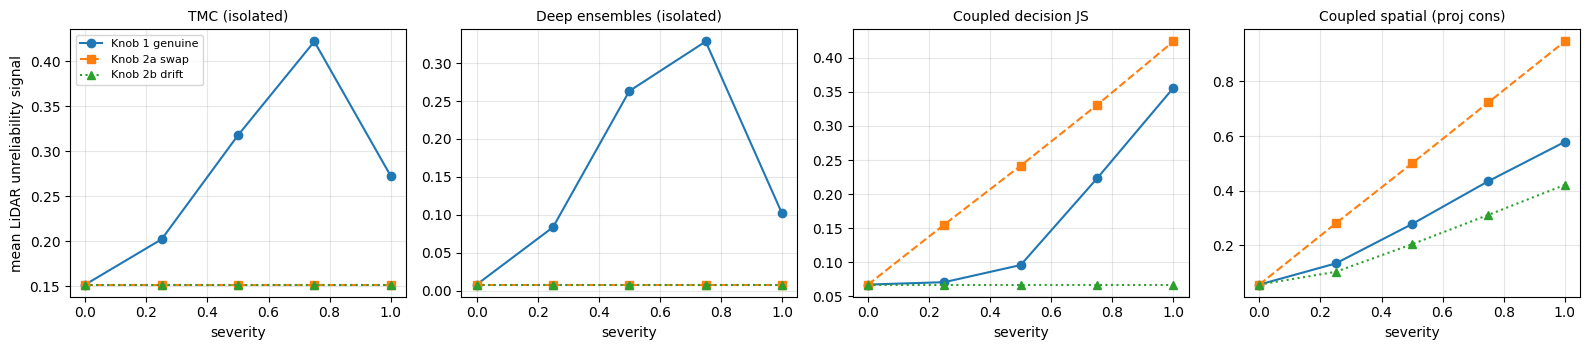

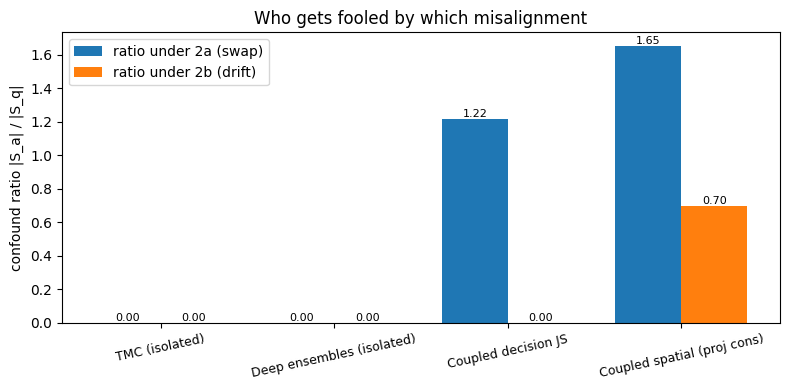

figures saved: step8_response_curves.png, step8_taxonomy.png


In [7]:
# ============ FIGURES ============
fig, axes = plt.subplots(1, len(methods), figsize=(4 * len(methods), 3.6), sharex=True)
for ax, (name, r) in zip(np.atleast_1d(axes), results.items()):
    c = r["curves"]
    ax.plot(SEVS, c["q"],  "o-",  label="Knob 1 genuine")
    ax.plot(SEVS, c["2a"], "s--", label="Knob 2a swap")
    ax.plot(SEVS, c["2b"], "^:",  label="Knob 2b drift")
    ax.set_title(name, fontsize=10); ax.set_xlabel("severity"); ax.grid(alpha=0.3)
np.atleast_1d(axes)[0].set_ylabel("mean LiDAR unreliability signal")
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig("step8_response_curves.png", dpi=150); plt.show()

names = list(results)
x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - w/2, [results[n]["r_2a"] for n in names], w, label="ratio under 2a (swap)")
b2 = ax.bar(x + w/2, [results[n]["r_2b"] for n in names], w, label="ratio under 2b (drift)")
for bars in (b1, b2):
    ax.bar_label(bars, fmt="%.2f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=12, fontsize=9)
ax.set_ylabel("confound ratio |S_a| / |S_q|")
ax.set_title("Who gets fooled by which misalignment")
ax.legend(); plt.tight_layout(); plt.savefig("step8_taxonomy.png", dpi=150); plt.show()
print("figures saved: step8_response_curves.png, step8_taxonomy.png")


## 4. Reading the result

**Predicted taxonomy, now with numbers above:**

- **Isolated methods (TMC, ensembles):** ratio ~0 under both knobs. Structural immunity carries over from Handwritten to real sensors, because their signal never touches the pairing or the calibration
- **Coupled decision (JS):** large ratio under 2a, near zero under 2b. Fooled by semantic misalignment, **blind** to geometric drift. A coupled method can pass one misalignment audit and fail another, which is why S_a must be reported per misalignment type
- **Coupled spatial (projection consistency):** large ratio under both. A deployed cross-sensor validation heuristic blames a pristine sensor for a mounting problem. That is the Masquerade on real geometry, with no self-built baseline in sight

**Caveats to log honestly:**

- Ratios are unstable when S_q is small. Always read the raw S_q, S_a columns next to the ratio
- At the current test size the slope fits are coarse. For paper numbers rerun Step 7 at N_FRAMES 500 to 1000, then rerun this notebook unchanged
- The 2b severity mapping (2 deg, 0.2 m at severity 1) is a defensible but chosen range. A stress test sweeping this cap belongs in the robustness section

**Campaign log entries:** the summary table, both figures, the gate numbers (Knob 1 v2 accuracy curve), and the TMC per-view and fused accuracies.

**What this unlocks next:** the cited-coupled-methods slot in the panel (agreement or attention-based fusion from the literature) now has a real-sensor harness to drop into, and the Mizoram data has a fully rehearsed protocol waiting for it.
